<a href="https://colab.research.google.com/github/NikhilBsc/BscTraining/blob/main/EDA_inclass.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
data = pd.read_csv("/content/Iris_dataset.csv")
df=pd.DataFrame(data)
df.head(5)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),flower_name
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [4]:
df.isna().sum()

,0
sepal length (cm),0
sepal width (cm),0
petal length (cm),0
petal width (cm),0
flower_name,0


In [5]:
df.duplicated().sum()

np.int64(1)

this dataset has no missing values at random , but looking at the duplicate records , there appears to be one , which has to be removed

In [6]:
df.drop_duplicates()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),flower_name
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [7]:
df.duplicated().sum()

np.int64(1)

In [9]:
df.drop_duplicates(inplace=True)
print(df.duplicated().sum())

0


here the duplicates appear to be zero , and now the data is unique and there are no missing values as such , so there is no need of imputing values

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 149 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  149 non-null    float64
 1   sepal width (cm)   149 non-null    float64
 2   petal length (cm)  149 non-null    float64
 3   petal width (cm)   149 non-null    float64
 4   flower_name        149 non-null    object 
dtypes: float64(4), object(1)
memory usage: 7.0+ KB


here , the datatype is float and every features has 149 rows/values and memory usage is also very minimal , which is kind of safe to move with

In [11]:
print("shape",df.shape)
print("size",df.size)

shape (149, 5)
size 745


the data set has 149 rows and 5 columns , including 4 features and one target variable (predicting the flower name ) and the dataset size is 745

In [14]:
#summary statistics
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,149.000000,149.000000,149.000000,149.000000
mean,5.843624,3.059732,3.748993,1.194631
std,0.830851,0.436342,1.767791,0.762622
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.300000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


this part demonstrates the stastistical part which has all the requred information about dataset

In [16]:
df.columns

Index(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)', 'flower_name'],
      dtype='object')

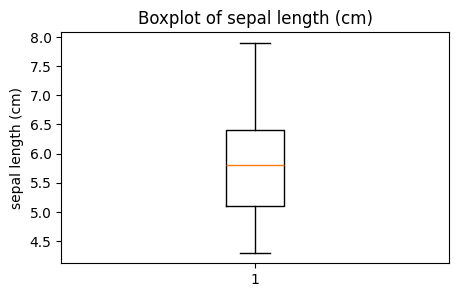

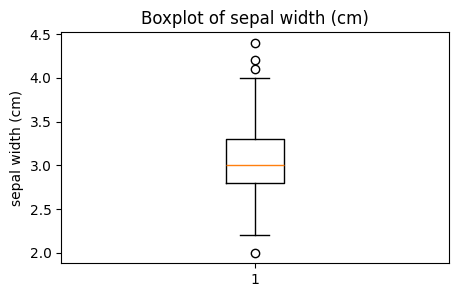

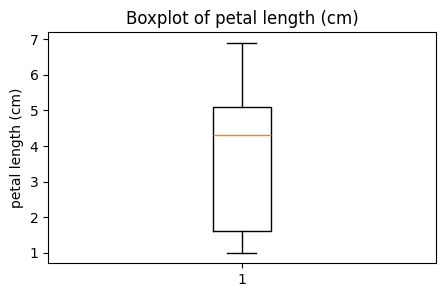

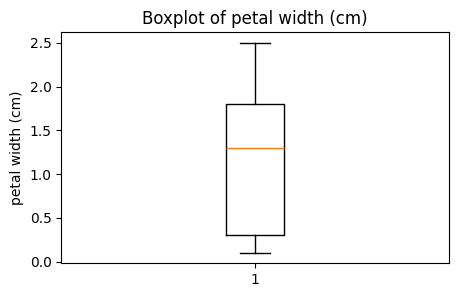

In [17]:
#vis
import matplotlib.pyplot as plt
columns = ["sepal length (cm)","sepal width (cm)","petal length (cm)","petal width (cm)"]
for col in columns:
    plt.figure(figsize=(5,3))
    plt.boxplot(df[col])
    plt.title(f"Boxplot of {col}")
    plt.ylabel(col)
    plt.show()

in the boxplot for sepal width , we can clearly see the outliers , few are above the quartile range and few below whiskers , but they are considers as valid datapoints , because they represent some part of sepal width

In [18]:
#finding outlier
Q1 = df['sepal width (cm)'].quantile(0.25)
Q3 = df['sepal width (cm)'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
outliers = df[(df['sepal width (cm)'] < lower) |(df['sepal width (cm)'] > upper)]
print(outliers)

    sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
15                5.7               4.4                1.5               0.4   
32                5.2               4.1                1.5               0.1   
33                5.5               4.2                1.4               0.2   
60                5.0               2.0                3.5               1.0   

   flower_name  
15      setosa  
32      setosa  
33      setosa  
60  versicolor  


In [ ]:
##there in sepal width , most datapoints lie between 2 and 4 , tho they are far away from central distribution , they are still valid , and we are going to retain the featurs

In [19]:
df_no_outliers = df[(df['sepal width (cm)'] >= lower) & (df['sepal width (cm)'] <= upper)]

In [ ]:
#here as part of the EDA ,I HAVE kept the values within IQR , even tho data points are not considered as outliers

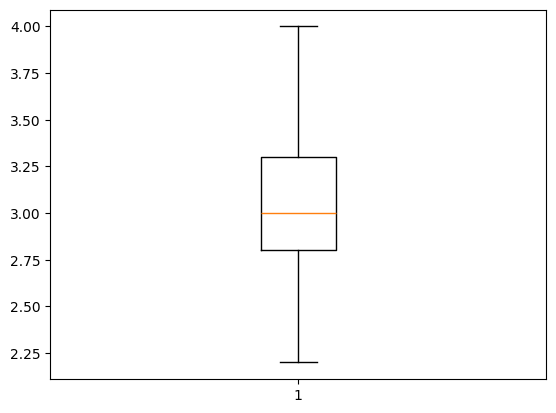

In [20]:
import matplotlib.pyplot as plt

plt.boxplot(df_no_outliers['sepal width (cm)'])
plt.show()

In [ ]:
##here as the boxplot shows there is no ouliers due to includig those points within the IQR

In [21]:
#distribution
print(df['flower_name'].value_counts())

flower_name
setosa        50
versicolor    50
virginica     49
Name: count, dtype: int64


In [ ]:
#HERE THE DATS set appears to be equally distributed , and there is no such class imbalance and can be easily retained

In [23]:
corr = df.drop('flower_name', axis=1).corr()
corr


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
sepal length (cm),1.000000,-0.118129,0.873738,0.820620
sepal width (cm),-0.118129,1.000000,-0.426028,-0.362894
petal length (cm),0.873738,-0.426028,1.000000,0.962772
petal width (cm),0.820620,-0.362894,0.962772,1.000000


In [ ]:
#here every features appears to be equally useful and important because , the correlation is close to +1 and -1 and we retain all features

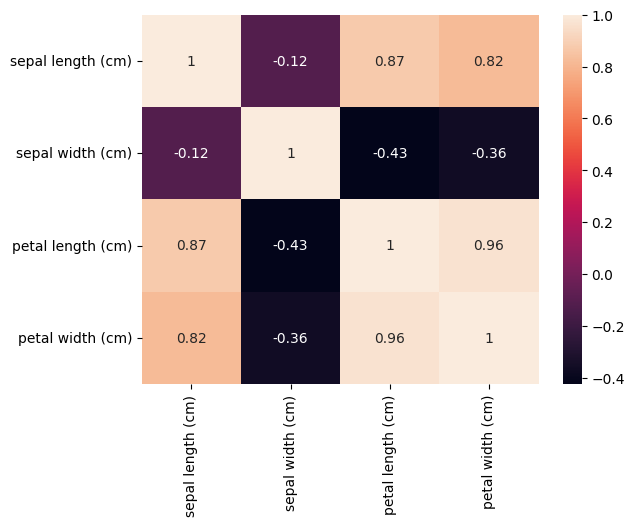

In [24]:
import seaborn as sns
sns.heatmap(corr, annot=True)
plt.show()

#multivariate Analysis and distribution

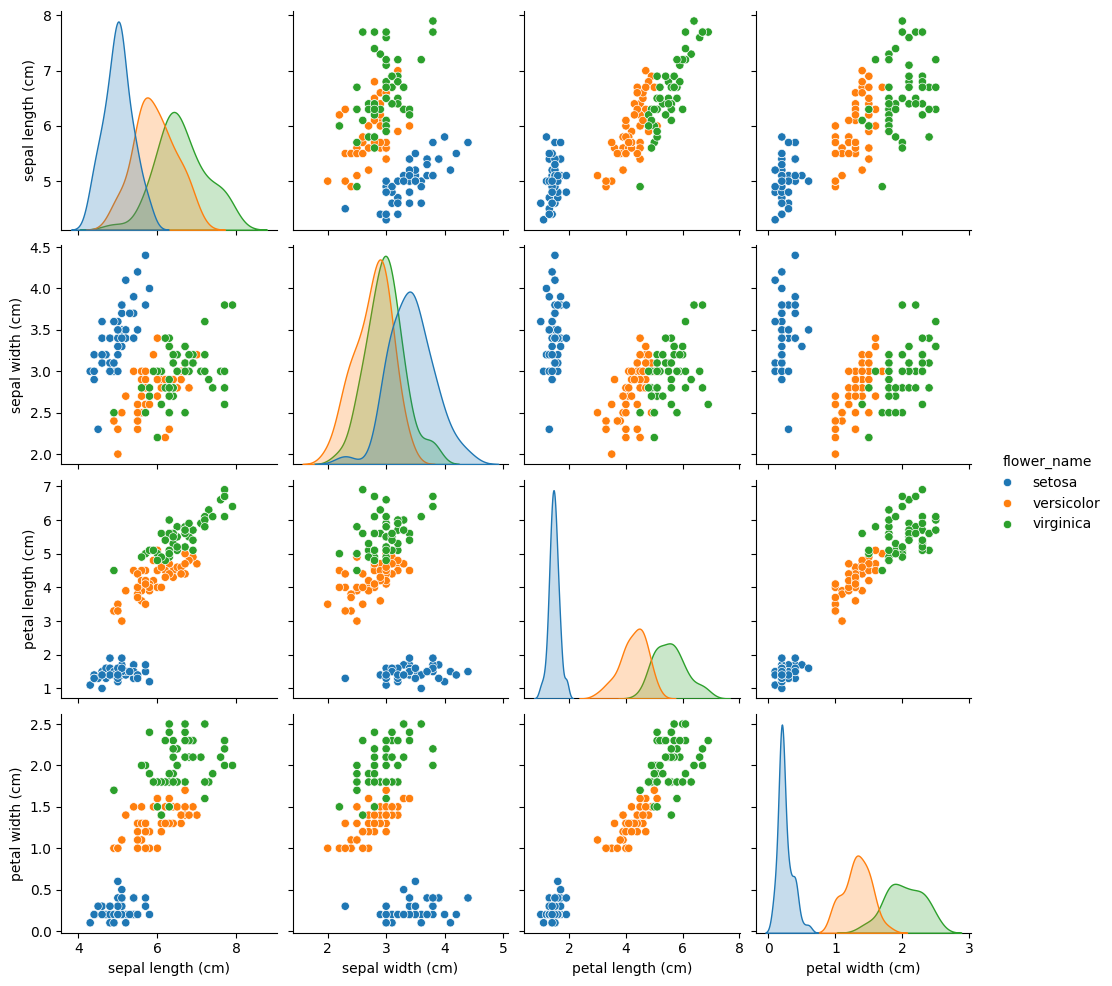

In [25]:
import seaborn as sns
sns.pairplot(df, hue='flower_name')
plt.show()

In [ ]:
# the above pairplot shows something very intersting , the petal length in x axis and petal width in y , shows linear incease , that is as x petal length increses , petal width also incrase
#while in most cases , the data points are more scatterd and difficlut to form a perfect cluster

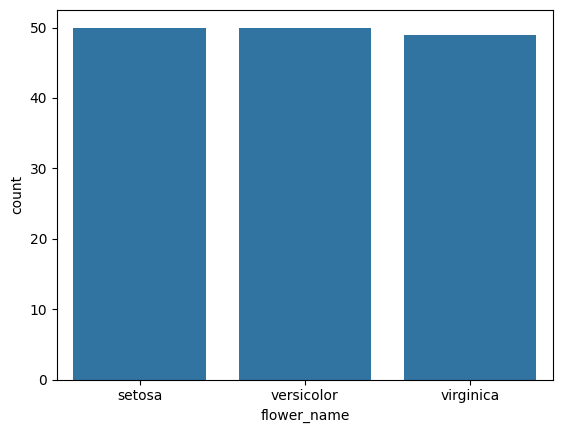

In [26]:
#counting the number of samples
sns.countplot(x='flower_name', data=df)
plt.show()

The dataset is nearly balanced across all three flower species. Setosa and Versicolor contain 50 samples each, while Virginica contains 49 samples after removing duplicate records.

In [27]:
df.groupby('flower_name').mean()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
flower_name,,,,
setosa,5.006000,3.428000,1.462000,0.246000
versicolor,5.936000,2.770000,4.260000,1.326000
virginica,6.604082,2.979592,5.561224,2.028571


#univariate Analysis

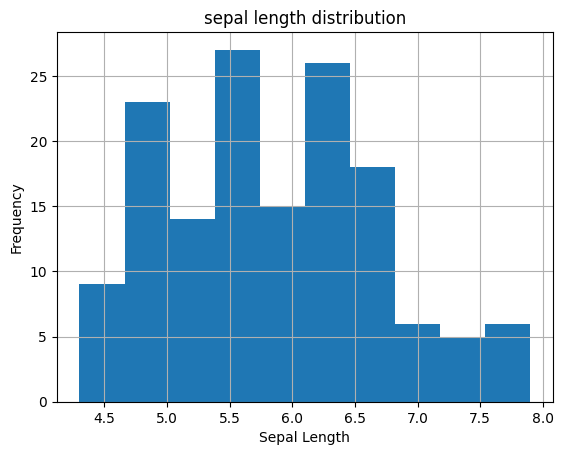

In [28]:
import matplotlib.pyplot as plt

df['sepal length (cm)'].hist()
plt.title('sepal length distribution')
plt.xlabel('Sepal Length')
plt.ylabel('Frequency')
plt.show()

In [ ]:
#Most flowers have a sepal length between 5 cm and 7 cm, indicating a fairly even distribution of values.

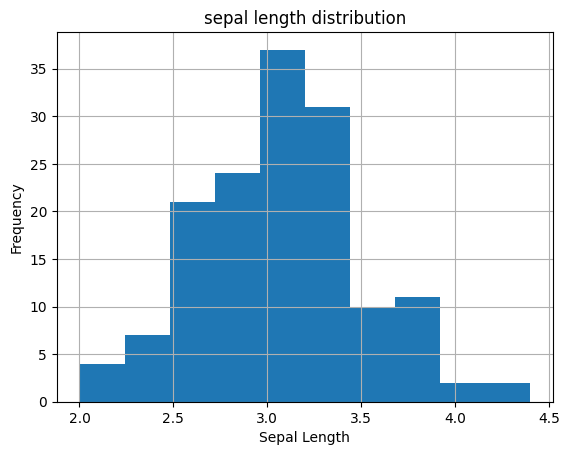

In [29]:
df['sepal width (cm)'].hist()
plt.title('sepal length distribution')
plt.xlabel('Sepal Length')
plt.ylabel('Frequency')
plt.show()

In [ ]:
#Sepal Width shows a slight right skew, indicating that a few flowers have relatively larger sepal widths compared to the majority of samples.

In [32]:
df.columns

Index(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)', 'flower_name'],
      dtype='object')

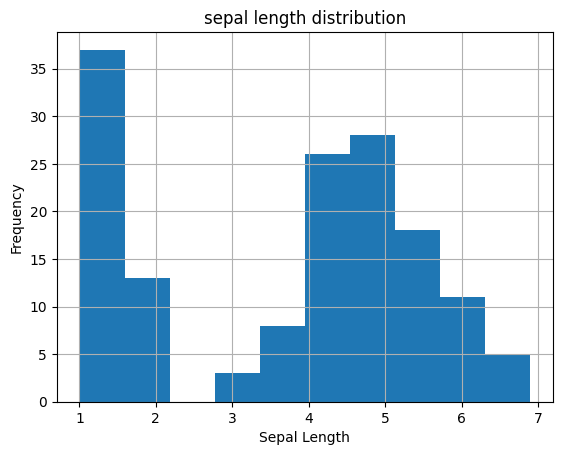

In [35]:
df['petal length (cm)'].hist()
plt.title('petal length distribution')
plt.xlabel('Sepal Length')
plt.ylabel('Frequency')
plt.show()

In [ ]:
#Petal Length exhibits a multimodal distribution, suggesting that different flower species have distinct petal length measurements.

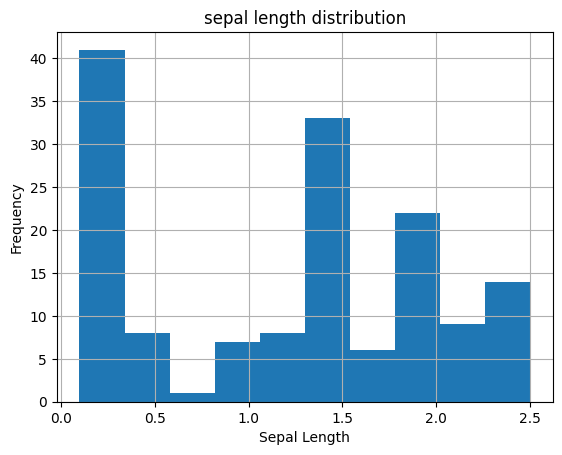

In [34]:
df['petal width (cm)'].hist()
plt.title('petal width distribution')
plt.xlabel('Sepal Length')
plt.ylabel('Frequency')
plt.show()

In [ ]:
#Petal Width is not normally distributed and exhibits multiple peaks. The distinct groups suggest that petal width varies significantly across flower species, making it an important feature for classification.

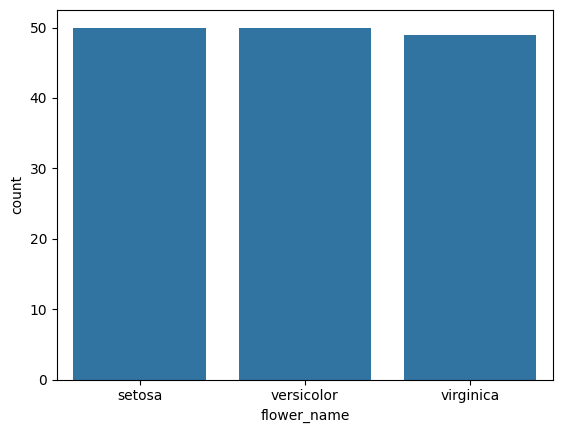

In [36]:
#counting the number of samples
sns.countplot(x='flower_name', data=df)
plt.show()

In [ ]:
#this clearly tells us that there is no class imbalce and all features are equally distributed , making it suitable for classofication task

In [ ]:
#bivariate Analysis


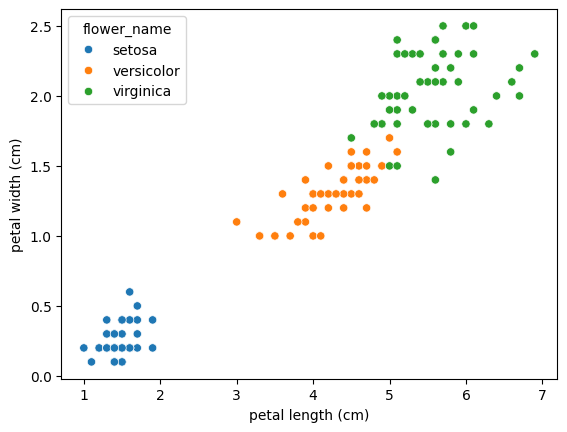

In [37]:
sns.scatterplot(
    x='petal length (cm)',
    y='petal width (cm)',
    hue='flower_name',
    data=df
)
plt.show()

In [ ]:
#A strong positive relationship exists between Petal Length and Petal Width. The three flower species form distinct clusters, with Setosa clearly separated from the others.

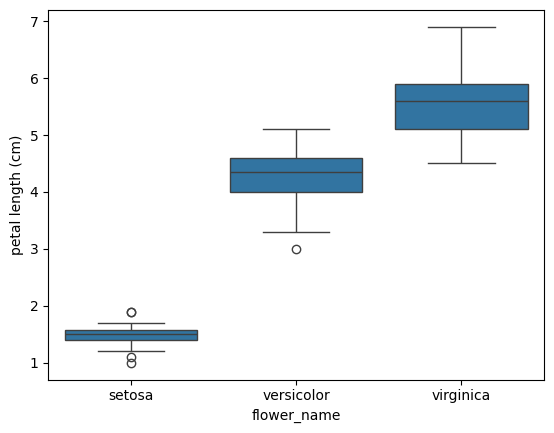

In [38]:
sns.boxplot(
    x='flower_name',
    y='petal length (cm)',data=df)
plt.show()

In [ ]:
#The median petal length differs significantly across species. Setosa has the lowest petal length, Versicolor has moderate values, and Virginica has the highest values, indicating that petal length is an important feature for distinguishing flower species.

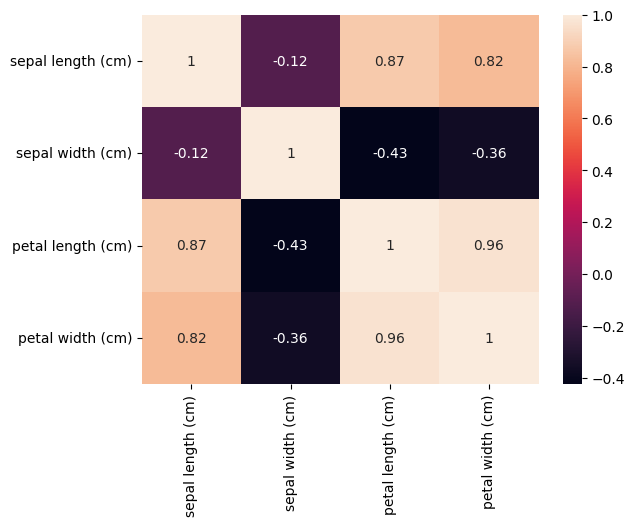

In [39]:
#multivariate Analysis with respect to heatmap
import seaborn as sns
sns.heatmap(corr, annot=True)
plt.show()

In [40]:
#checking for class skeweness
df.drop('flower_name', axis=1).skew()

,0
sepal length (cm),0.312826
sepal width (cm),0.307149
petal length (cm),-0.263101
petal width (cm),-0.090076


In [ ]:
#Sepal Length and Sepal Width show slight positive skewness, while Petal Length and Petal Width show slight negative skewness ,Overall, the distributions are fairly balanced and do not exhibit severe skewness.

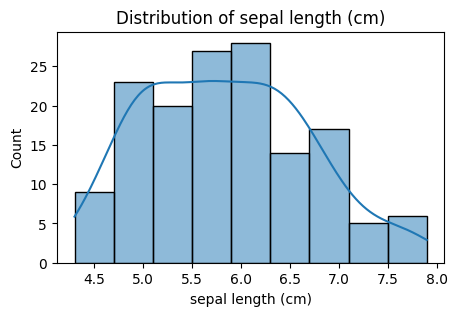

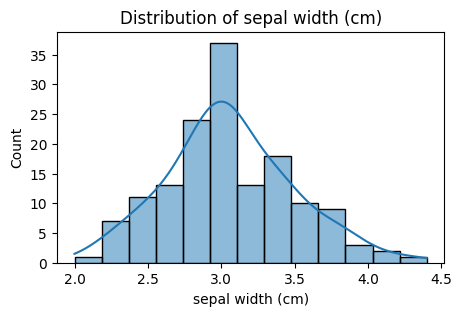

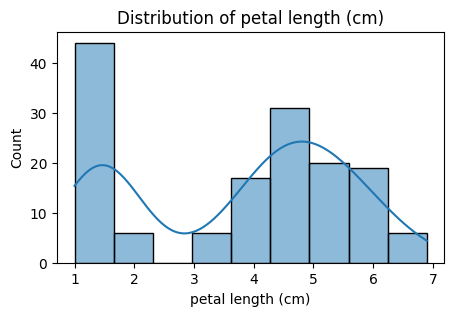

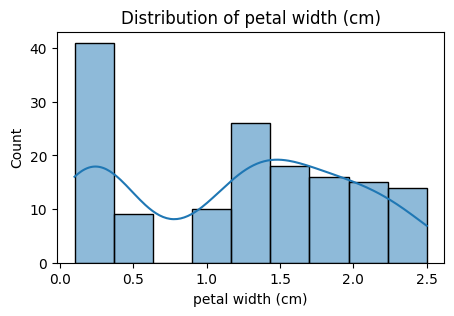

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt
cols = ["sepal length (cm)","sepal width (cm)","petal length (cm)","petal width (cm)"]
for col in cols:
    plt.figure(figsize=(5,3))
    sns.histplot(df[col],kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

In [ ]:
#the above histplot with KDE clearly shows that while the sepal length is almost normally distributed , which is kind of difficult to differentiate between flowers only based on width
#but also at the same time petal length and petal width shows , multiple peaks , which clearly tells that , there are different classes and it is unevenly distributed making iris data set suitable for classification task

#report
EDA primarily works based on pnadas and i have used DataFrame as datastructre to visulaize the CSV in form of tabular data

The Iris dataset was loaded and explored using info(), shape(), and summary statistics to understand its structure and feature distributions. The dataset contains four numerical features and one categorical target variable. Missing value analysis showed no null values, while duplicate analysis identified 2 duplicate records, which were removed. Histograms indicated that sepal features are fairly distributed, whereas petal features show distinct clusters corresponding to different flower species. Boxplot analysis identified a few outliers in Sepal Width; however, these observations appear valid and were retained.

Skewness values were close to zero for all numerical features, indicating approximately symmetric distributions. The countplot showed that the dataset is nearly balanced across all flower species. Bivariate analysis revealed a strong positive relationship between Petal Length and Petal Width, with petal width increasing as petal length increases. The species-wise boxplot showed a clear increase in petal length from Setosa to Versicolor to Virginica. Correlation analysis and the heatmap confirmed a strong correlation between petal-related features. Finally, the pairplot showed that Setosa forms a clearly separable cluster, while Versicolor and Virginica exhibit slight overlap. Overall, the dataset is clean, balanced, and well-suited for classification tasks, with petal measurements being the most informative features.